# Extended Kalman Filter for Differential Drive AMR Localization

- **Author:** Eduardo de Jesús Dávila Meza, Ph.D.
- **LinkedIn:** [EduardoDavilaMeza](https://www.linkedin.com/in/eduardodavilameza/)
- **Institutional Email:** [eduardo.davila.meza@tec.mx](mailto:eduardo.davila.meza@tec.mx)

### Adaptive EKF Simulation Notebook

The notebook demonstrates:

1. EKF localization for a differential-drive AMR
2. Fusion of wheel encoder and IMU information
3. Influence of covariance matrices $Q$ and $R$
4. Adaptive covariance estimation strategies

### Conceptual Reference
Section 5.2.2 “EKF–Weight Estimation” from the chapter “Dual Extended Kalman Filter Methods”, by Eric A. Wan and Alex T. Nelson, included in the edited book by Simon Haykin (2001), *Kalman Filtering and Neural Networks*.

## 1. Preliminary Theory

### 1.1 State Estimation in Robotics

Autonomous mobile robots cannot directly measure their exact state due to:

* sensor noise
* wheel slippage
* IMU drift
* quantization
* environmental uncertainty

Instead, the robot estimates its state probabilistically.

The localization problem consists of estimating:

$ x_k = \begin{bmatrix} x \ y \ \theta \end{bmatrix} $

where:

* $x$: position in X
* $y$: position in Y
* $\theta$: robot orientation

### 1.2 Bayesian Filtering Concept

The Kalman Filter and Extended Kalman Filter are recursive Bayesian estimators.

The filter alternates between:

1. Prediction step
2. Correction step

#### Prediction

The robot predicts its next state using:

* kinematic model
* encoder data
* IMU angular velocity

#### Correction

The robot corrects the prediction using:

* noisy measurements
* sensor observations

### 1.3 Why the EKF is Necessary

The standard Kalman Filter assumes:

* linear system dynamics
* linear measurement model

However, mobile robot kinematics are nonlinear:

$ x_{k+1} = x_k + v\Delta t \cos(\theta_k) $

$ y_{k+1} = y_k + v\Delta t \sin(\theta_k) $

Therefore, the Extended Kalman Filter (EKF) linearizes the nonlinear system using Jacobians.

### 1.4 Process Noise and Measurement Noise

The EKF depends strongly on two covariance matrices:

* $Q$: process covariance matrix
* $R$: measurement covariance matrix

These matrices determine how much the filter trusts:

* the robot motion model
* the sensor measurements

#### Process Covariance $Q$

Q represents uncertainty in the robot prediction model.

Examples:

* wheel slip
* uneven terrain
* encoder quantization
* imperfect kinematics

Large $Q$:

* prediction is considered unreliable
* the filter trusts measurements more
* estimation becomes more reactive but noisier

Small $Q$:

* prediction is considered reliable
* the filter trusts the motion model more
* estimation becomes smoother

#### Measurement Covariance $R$

R represents uncertainty in sensor measurements.

Examples:

* IMU noise
* GPS noise
* localization uncertainty
* beacon inaccuracies

Large $R$:

* measurements are considered unreliable
* the filter trusts prediction more
* estimation becomes smoother but less responsive

Small $R$:

* measurements are considered reliable
* the filter follows measurements more closely
* estimation becomes more reactive

### 1.5 Adaptive EKF

In real robotics systems:

* sensor quality changes
* wheel slip changes
* environment changes

Therefore:

* fixed $Q$ and $R$ may become suboptimal

Adaptive EKF techniques dynamically estimate:

* $Q_k$
* $R_k$

during execution.

## 2. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 3. Differential Drive AMR Model

### 3.1 Differential Drive Kinematics

The robot uses:

* linear velocity $v$
* angular velocity $\omega$

to update its pose.

State vector:

$ x = \begin{bmatrix} x \ y \ \theta \end{bmatrix} $

Control vector:

$ u = \begin{bmatrix} v \ \omega \end{bmatrix} $

### 3.2 Angle Normalization

In [2]:
def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

### 3.3 Motion Model

In [3]:
def motion_model(x, u, dt):
    px, py, theta = x
    v, omega = u

    px_new = px + v * dt * np.cos(theta)
    py_new = py + v * dt * np.sin(theta)
    theta_new = theta + omega * dt

    theta_new = wrap_angle(theta_new)

    return np.array([px_new, py_new, theta_new])

### 3.4 Jacobian of the Motion Model

The EKF requires the Jacobian:
$ F_k = \frac{\partial f}{\partial x} $

In [4]:
def jacobian_F(x, u, dt):
    _, _, theta = x
    v, _ = u

    F = np.array([
        [1, 0, -v * dt * np.sin(theta)],
        [0, 1,  v * dt * np.cos(theta)],
        [0, 0, 1]
    ])
    return F

## 4. Measurement Model

### 4.1 Simulated Localization Sensor

For educational simplicity, the robot receives noisy measurements of:

$ z = \begin{bmatrix} x_m \ y_m \ \theta_m \end{bmatrix} $

This emulates:

* LiDAR localization
* vision localization
* beacon systems
* GPS

### 4.2 Measurement Function

In [5]:
def measurement_model(x):
    return x

### 4.3 Measurement Jacobian

Since the measurement model is linear:

$ H = I $

In [6]:
def jacobian_H():
    return np.eye(3)

## 5. EKF Equations

### 5.1 Prediction Step

In [7]:
def ekf_predict(x, P, u, Q, dt):
    F = jacobian_F(x, u, dt)

    x_pred = motion_model(x, u, dt)

    P_pred = F @ P @ F.T + Q

    return x_pred, P_pred

### 5.2 Correction Step

In [8]:
def ekf_update(x_pred, P_pred, z, R, epsilon=1e-6):
    H = jacobian_H()

    z_pred = measurement_model(x_pred)

    innovation = z - z_pred
    innovation[2] = wrap_angle(innovation[2])

    S = H @ P_pred @ H.T + R

    K = P_pred @ H.T @ np.linalg.inv(S)

    x_upd = x_pred + K @ innovation

    I = np.eye(len(x_pred))
    
    # A) Standard covariance update
    # P_upd = (I - K @ H) @ P_pred

    # B) Joseph stabilized covariance update
    P_upd = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T

    # Force symmetry
    P_upd = 0.5 * (P_upd + P_upd.T)

    # Regularization to prevent singularity
    P_upd += epsilon * np.eye(P_upd.shape[0])

    return x_upd, P_upd, innovation, K

## 6. Simulation Configuration

### 6.1 Time Parameters

In [9]:
dt = 0.1
steps = 300

### 6.2 Ground Truth Trajectory

The robot follows a curved trajectory.

In [10]:
true_states = np.zeros((steps, 3))

x_true = np.array([0.0, 0.0, 0.0])

v_true = 1.0

for k in range(steps):

    omega_true = 0.3 * np.sin(0.05 * k)

    u_true = np.array([v_true, omega_true])

    x_true = motion_model(x_true, u_true, dt)

    true_states[k] = x_true

## 7. Sensor Simulation

### 7.1 Encoder and IMU Noise

In [11]:
encoder_std = 0.05
imu_std = np.deg2rad(2.0)

measurement_std_x = 0.5
measurement_std_y = 0.5
measurement_std_theta = np.deg2rad(5.0)

### 7.2 Generate Noisy Measurements

In [12]:
measurements = np.zeros((steps, 3))
controls = np.zeros((steps, 2))

for k in range(steps):
    omega_true = 0.3 * np.sin(0.05 * k)

    v_noisy = v_true + np.random.randn() * encoder_std

    omega_noisy = omega_true + np.random.randn() * imu_std

    controls[k] = np.array([v_noisy, omega_noisy])

    meas_noise = np.array([
        np.random.randn() * measurement_std_x,
        np.random.randn() * measurement_std_y,
        np.random.randn() * measurement_std_theta
    ])

    z = true_states[k] + meas_noise

    z[2] = wrap_angle(z[2])

    measurements[k] = z

## 8. Strategy 1 — Fixed Covariance EKF

### 8.1 Fixed Covariance Matrices

In [13]:
# The larger the Q, the more the filter trusts the measurements over the predictions, leading to more responsive but potentially noisier estimates. The smaller the Q, the more it trusts the predictions, which can lead to smoother but potentially less accurate estimates if the model is not perfect.
Q_fixed = np.diag([0.05, 0.04, np.deg2rad(0.03)]) # np.diag([0.05, 0.05, np.deg2rad(1.0)])

# The larger the R, the more the filter trusts the prediction over the measurements, leading to smoother but potentially less accurate estimates. The smaller the R, the more it trusts the measurements, which can lead to noisier estimates if the measurements are very noisy.
R_fixed = np.diag([5, 4, np.deg2rad(3.0)]) # np.diag([0.5, 0.5, np.deg2rad(5.0)])

### 8.2 EKF Initialization

In [14]:
x_est = np.array([0.0, 0.0, 0.0])

P = np.eye(3)

estimates_fixed = np.zeros((steps, 3))

errors_fixed = np.zeros(steps)

### 8.3 EKF Loop

In [15]:
for k in range(steps):
    u = controls[k]

    z = measurements[k]

    x_pred, P_pred = ekf_predict(x_est, P, u, Q_fixed, dt)

    x_est, P, innovation, K = ekf_update(x_pred, P_pred, z, R_fixed)

    estimates_fixed[k] = x_est

    errors_fixed[k] = np.linalg.norm(true_states[k, 0:2] - x_est[0:2])

## 9. Strategy 2 — Adaptive Covariance from P

### 9.1 Theory

This strategy updates:

$ Q_k = \alpha_Q \cdot diag(P_k) $

$ R_k = \alpha_R \cdot diag(P_k) $

This creates adaptive covariance scaling.

### 9.2 Initialization

Large alpha:

- larger covariance
- more uncertainty

Small alpha:

- smaller covariance
- less uncertainty

In [16]:
# Scaling factors applied to the covariance matrix P.
# Larger values increase the estimated uncertainty.
# Smaller values reduce the estimated uncertainty.
alpha_q = 0.99 # TODO: Correct to 0.001, for example
alpha_r = 0.999 # TODO: Correct to 0.005, for example

x_est = np.array([0.0, 0.0, 0.0])

P = np.eye(3)

estimates_adaptive_P = np.zeros((steps, 3))

errors_adaptive_P = np.zeros(steps)

Q_history_P = []
R_history_P = []

### 9.3 Adaptive EKF Loop

In [17]:
for k in range(steps):
    Q = alpha_q * np.diag(np.diag(P))
    Q_history_P.append(np.diag(Q))

    R = alpha_r * np.diag(np.diag(P))
    R_history_P.append(np.diag(R))

    u = controls[k]

    z = measurements[k]

    x_pred, P_pred = ekf_predict(x_est, P, u, Q, dt)

    x_est, P, innovation, K = ekf_update(x_pred, P_pred, z, R)

    estimates_adaptive_P[k] = x_est

    errors_adaptive_P[k] = np.linalg.norm(true_states[k, 0:2] - x_est[0:2])

## 10. Strategy 3 — Innovation-Based Adaptive EKF

### 10.1 Theory

The innovation is:

$ e_k = z_k - h(\hat{x}_k^-) $

Adaptive covariance update:

$ Q_k = (1-a)Q_{k-1} + aK_ke_ke_k^TK_k^T $

$ R_k = (1-b)R_{k-1} + bK_ke_ke_k^TK_k^T $

This adaptive strategy updates:

- $R$ according to measurement innovation statistics
- $Q$ according to prediction correction statistics

The objective is to dynamically adapt the EKF to changing robot and sensor conditions.


### 10.2 Initialization

Large $a$:

- faster adaptation of $Q_k$
- more reactive covariance estimation
- potentially noisier/unstable

Small $a$:

- slower adaptation
- smoother covariance evolution
- more stable

Same for $b$ for $R_k$.

In [18]:
## Adaptation gains for the covariance estimation ##
# 
# Larger values:
# * faster adaptation
# * more reactive covariance updates
# * potentially noisier or unstable behavior
# 
# Smaller values:
# * slower adaptation
# * smoother covariance evolution
# * greater numerical stability
a = 0.001
b = 0.01

Q = Q_fixed # np.diag([0.05, 0.05, np.deg2rad(1.0)])
R = R_fixed # np.diag([0.5, 0.5, np.deg2rad(5.0)])

x_est = np.array([0.0, 0.0, 0.0])

P = np.eye(3)

estimates_innovation = np.zeros((steps, 3))

errors_innovation = np.zeros(steps)

R_history_innovation = []
Q_history_innovation = []
innovation_norms = []

### 10.3 Innovation-Based EKF Loop

In [19]:
for k in range(steps):
    u = controls[k]

    z = measurements[k]

    x_pred, P_pred = ekf_predict(x_est, P, u, Q, dt)

    x_est, P, innovation, K = ekf_update(x_pred, P_pred, z, R)

    # Innovation covariance approximation
    innovation_cov = np.outer(innovation, innovation)

    ## Adaptive process covariance update for Q ##
    Q = (1 - a) * Q + a * K @ innovation_cov @ K.T
    Q = 0.5 * (Q + Q.T) # Force symmetry
    Q_diag = np.clip(np.diag(Q), 1e-6, 10.0) # Prevent covariance explosion/collapse
    Q = np.diag(Q_diag)
    Q_history_innovation.append(np.diag(Q))

    ## Adaptive process covariance update for R ##
    R = (1 - b) * R + b * K @ innovation_cov @ K.T
    R = 0.5 * (R + R.T) # Force symmetry
    R_diag = np.clip(np.diag(R), 1e-6, 10.0) # Prevent covariance explosion/collapse
    R = np.diag(R_diag)
    R_history_innovation.append(np.diag(R))

    innovation_norms.append(np.linalg.norm(innovation))

    estimates_innovation[k] = x_est

    errors_innovation[k] = np.linalg.norm(true_states[k, 0:2] - x_est[0:2])

## 11. Visualization — Trajectories

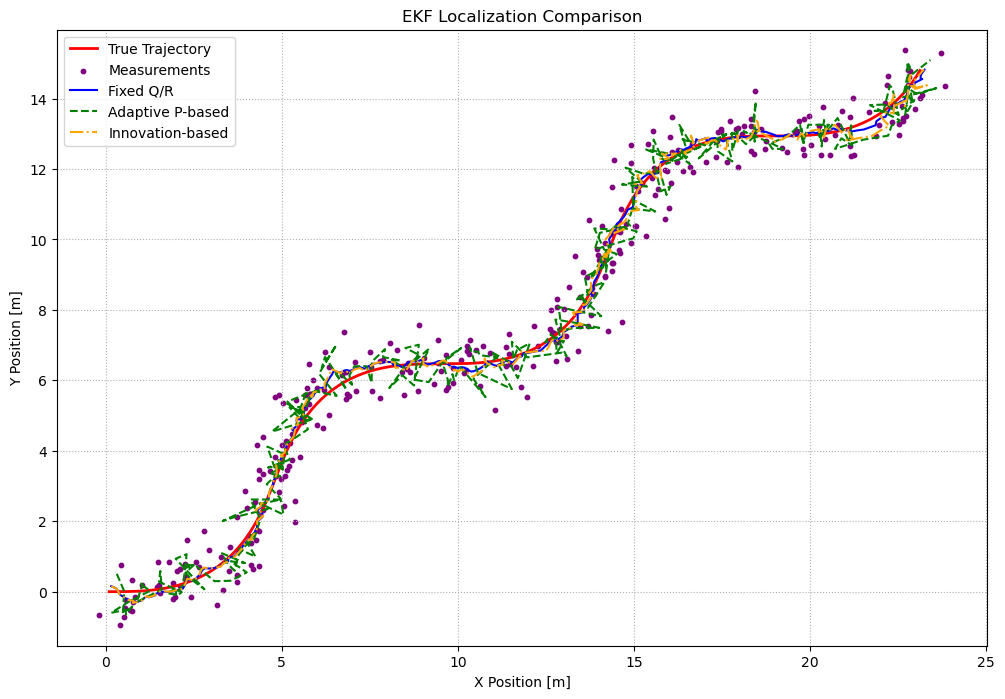

In [20]:
plt.figure(figsize=(12, 8))
plt.plot(true_states[:,0], true_states[:,1], label='True Trajectory', linewidth=2, color='red')
plt.scatter(measurements[:,0], measurements[:,1], s=10, label='Measurements', color='purple')
plt.plot(estimates_fixed[:,0], estimates_fixed[:,1], label='Fixed Q/R', color='blue')
plt.plot(estimates_adaptive_P[:,0], estimates_adaptive_P[:,1], label='Adaptive P-based', linestyle='--', color='green')
plt.plot(estimates_innovation[:,0], estimates_innovation[:,1], label='Innovation-based', linestyle='-.', color='orange')
plt.grid(True, linestyle=':')
plt.axis('equal')
plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.title('EKF Localization Comparison')
plt.legend()
plt.show()

## 12. Visualization — Position Error

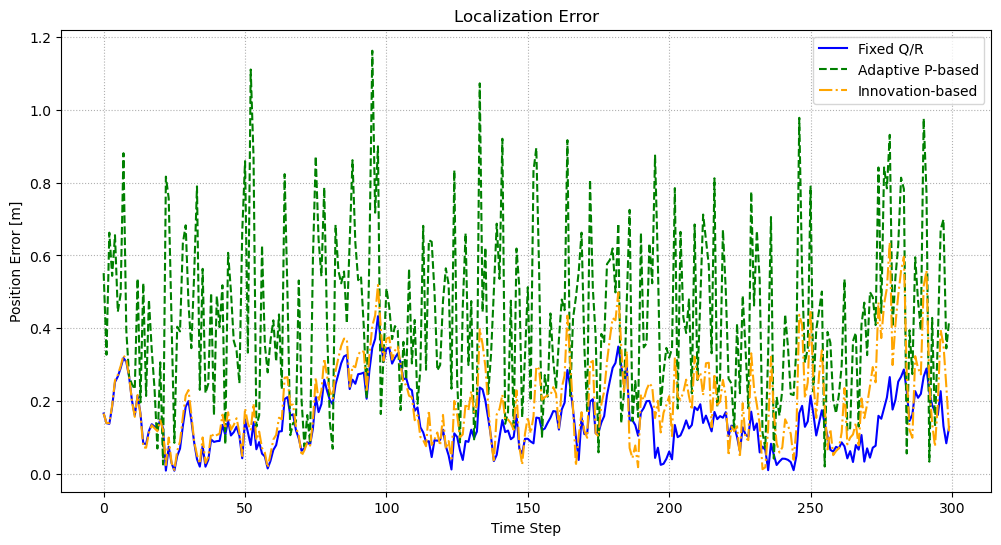

In [21]:
plt.figure(figsize=(12,6))
plt.plot(errors_fixed, label='Fixed Q/R', color='blue')
plt.plot(errors_adaptive_P, label='Adaptive P-based', linestyle='--', color='green')
plt.plot(errors_innovation, label='Innovation-based', linestyle='-.', color='orange')
plt.grid(True, linestyle=':')
plt.xlabel('Time Step')
plt.ylabel('Position Error [m]')
plt.title('Localization Error')
plt.legend()
plt.show()

## 13. Visualization — Adaptive Covariances

### 13.1 P-Based Covariance Evolution

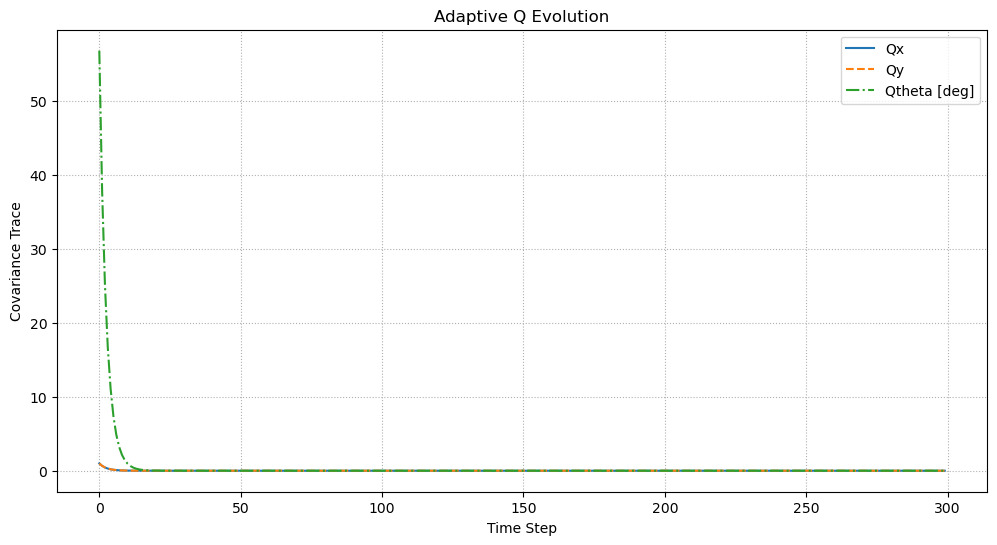

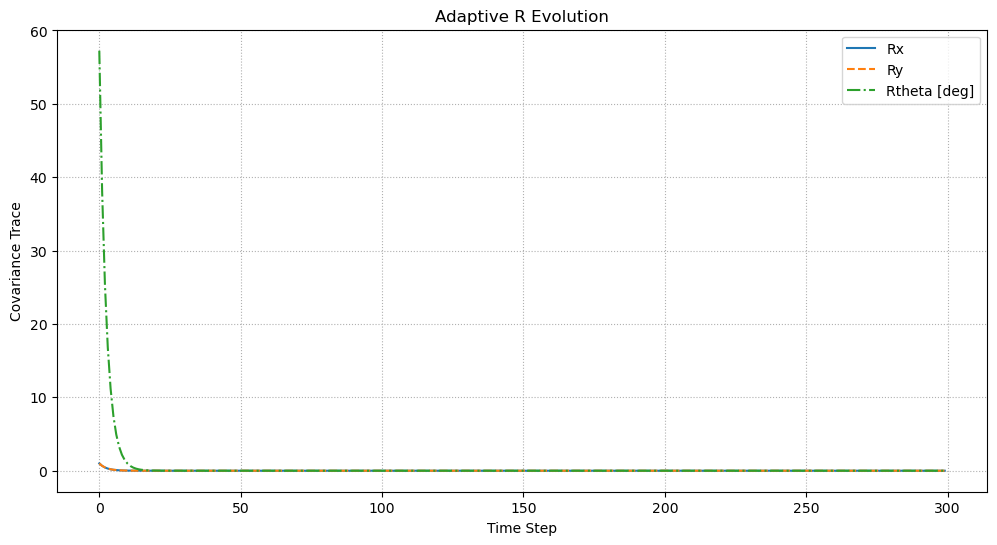

In [22]:
Q_history_P = np.array(Q_history_P)

plt.figure(figsize=(12,6))
plt.plot(Q_history_P[:,0], label='Qx')
plt.plot(Q_history_P[:,1], label='Qy', linestyle='--')
plt.plot(np.rad2deg(Q_history_P[:,2]), label='Qtheta [deg]', linestyle='-.')
plt.grid(True, linestyle=':')
plt.title('Adaptive Q Evolution')
plt.xlabel('Time Step')
plt.ylabel('Covariance Trace')
plt.legend()
plt.show()

R_history_P = np.array(R_history_P)

plt.figure(figsize=(12,6))
plt.plot(R_history_P[:,0], label='Rx')
plt.plot(R_history_P[:,1], label='Ry', linestyle='--')
plt.plot(np.rad2deg(R_history_P[:,2]), label='Rtheta [deg]', linestyle='-.')
plt.grid(True, linestyle=':')
plt.title('Adaptive R Evolution')
plt.xlabel('Time Step')
plt.ylabel('Covariance Trace')
plt.legend()
plt.show()


### 13.2 Innovation-Based R Evolution

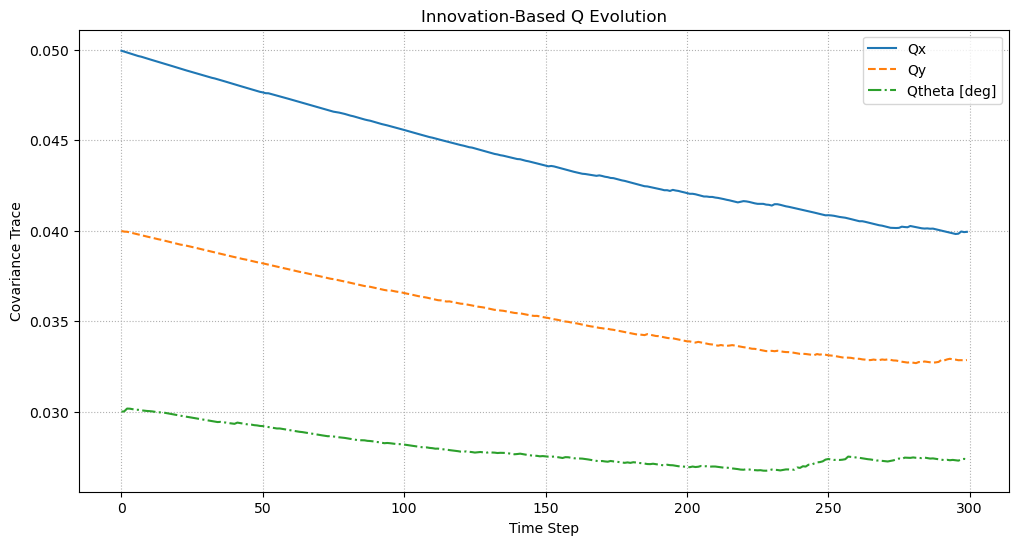

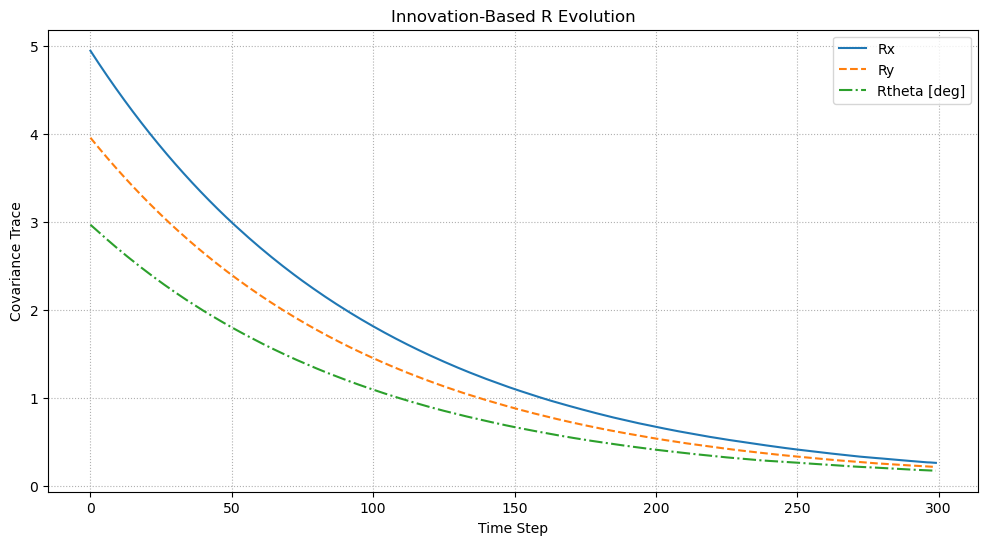

In [23]:
Q_history_innovation = np.array(Q_history_innovation)

plt.figure(figsize=(12,6))
plt.plot(Q_history_innovation[:,0], label='Qx')
plt.plot(Q_history_innovation[:,1], label='Qy', linestyle='--')
plt.plot(np.rad2deg(Q_history_innovation[:,2]), label='Qtheta [deg]', linestyle='-.')
plt.grid(True, linestyle=':')
plt.title('Innovation-Based Q Evolution')
plt.xlabel('Time Step')
plt.ylabel('Covariance Trace')
plt.legend()
plt.show()

R_history_innovation = np.array(R_history_innovation)

plt.figure(figsize=(12,6))
plt.plot(R_history_innovation[:,0], label='Rx')
plt.plot(R_history_innovation[:,1], label='Ry', linestyle='--')
plt.plot(np.rad2deg(R_history_innovation[:,2]), label='Rtheta [deg]', linestyle='-.')
plt.grid(True, linestyle=':')
plt.title('Innovation-Based R Evolution')
plt.xlabel('Time Step')
plt.ylabel('Covariance Trace')
plt.legend()
plt.show()

## 14. Visualization — Innovation Norm

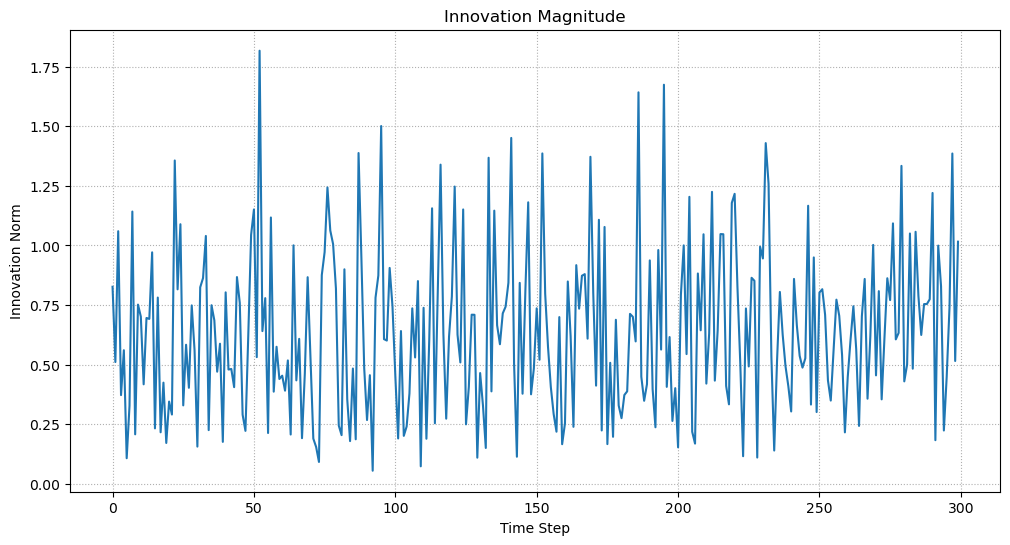

In [24]:
plt.figure(figsize=(12,6))
plt.plot(innovation_norms)
plt.grid(True, linestyle=':')
plt.xlabel('Time Step')
plt.ylabel('Innovation Norm')
plt.title('Innovation Magnitude')
plt.show()

## 15. RMSE Comparison# 7.2 Generate Noisy Measurements

### 15.1 Compute RMSE

In [25]:
rmse_fixed = np.sqrt(np.mean(errors_fixed**2))
rmse_adaptive_P = np.sqrt(np.mean(errors_adaptive_P**2))
rmse_innovation = np.sqrt(np.mean(errors_innovation**2))

print("RMSE Fixed Q/R:", rmse_fixed)
print("RMSE Adaptive P:", rmse_adaptive_P)
print("RMSE Innovation:", rmse_innovation)

RMSE Fixed Q/R: 0.1684899938775453
RMSE Adaptive P: 0.49241984863312915
RMSE Innovation: 0.23328216252450237


## 16. Discussion and Analysis

In autonomous mobile robot localization systems, the tuning of the EKF covariance matrices Q and R strongly affects:

* odometry drift
* localization smoothness
* responsiveness
* numerical stability

Incorrect covariance tuning is one of the most common causes of localization instability in autonomous robots.

In ROS 2 localization systems, poor covariance estimation may lead to:

* excessive drift
* oscillatory localization
* delayed corrections
* inconsistent sensor fusion
* filter divergence

### 16.1 Fixed Covariance EKF

Advantages:

* simple implementation
* computationally efficient
* predictable behavior
* widely used in practical systems

Disadvantages:

* requires manual tuning
* sensitive to environmental changes
* assumes stationary noise statistics
* may diverge under model mismatch

### 16.2 P-Based Adaptive EKF

Advantages:

* automatic covariance scaling
* smoother covariance evolution
* improved robustness to uncertainty variations

Disadvantages:

* heuristic adaptation strategy
* adaptation may become slow
* covariance estimation depends strongly on P

### 16.3 Innovation-Based Adaptive EKF

Advantages:

* adapts dynamically to sensor inconsistencies
* responds to prediction errors
* more realistic for robotics applications
* useful under changing operating conditions

Disadvantages:

* higher computational cost
* requires adaptation-gain tuning
* can become numerically unstable
* may suffer covariance explosion without regularization